In [1]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import plotly.express as px

In [2]:
#from src.jax_resnet.model import init_params, batched_forward, sample_dropout_mask, batched_forward_dropout, FiniteResNetParams, batched_forward_track, batched_forward_dropout_track
from src.jax_resnet.model import init_params, FiniteResNetParams, relu, batched_forward_track
from src.jax_resnet.training import train_scan_jit, train_dropout_scan_jit, train_ram_scan_jit, train_scan_ce_jit, train_dropout_scan_ce_jit, train_ram_scan_ce_jit

In [3]:
from src.utils import make_dataset_mnist

In [4]:
d_in, d_out, seed = 784, 2, 42
N=100
X_train, Y_train, X_test, Y_test = make_dataset_mnist(N=N, seed=seed, digits=[4,7])

In [5]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((80, 784), (80, 2), (20, 784), (20, 2))

In [6]:
configurations = [   
    (10, 4, 4),
    (10, 4, 8),
    # (10, 4, 4),
    # (10, 40, 4),
    # (10, 40, 40),
    # (10, 400, 40),
    # (10, 400, 400),
    # (10, 2000, 15),
    # Add more as needed
]

print("Configurations to load:", configurations)


Configurations to load: [(10, 4, 4), (10, 4, 8)]


In [7]:
def compute_parameter_distance_metrics(final_params_noisy, final_params_ref, histories_noisy, histories_ref, variant_name=None):
    """
    Compute parameter distance metrics between noisy (DO/RaM) and reference (GD) solutions.
    
    Args:
        final_params_noisy: params from dropout/ram training (dict of lists or single params)
        final_params_ref: reference params (e.g., from GD)
        histories_noisy: histories from dropout/ram training (dict of lists or single history)
        histories_ref: reference history (e.g., from GD)
        variant_name: variant identifier for printing
    
    Returns:
        Dictionary with Delta_U, Delta_V, Delta_h metrics (averaged over repetitions if applicable)
    """
    
    # Handle both single runs and multiple repetitions
    if isinstance(final_params_noisy, list):
        num_reps = len(final_params_noisy)
        is_repeated = True
    else:
        num_reps = 1
        final_params_noisy = [final_params_noisy]
        histories_noisy = [histories_noisy]
        is_repeated = False
    
    all_delta_u = []
    all_delta_v = []
    all_delta_h = []
    
    for rep_idx in range(num_reps):
        params_noisy = final_params_noisy[rep_idx]
        params_ref = final_params_ref[rep_idx]
        history_noisy = histories_noisy[rep_idx]
        history_ref = histories_ref[rep_idx]
        
        U_noisy = np.asarray(params_noisy.U)  # (L, M, D)
        V_noisy = np.asarray(params_noisy.V)  # (L, M, D)
        
        U_ref = np.asarray(params_ref.U)      # (L, M, D)
        V_ref = np.asarray(params_ref.V)      # (L, M, D)
        
        # Compute Delta_U: max_l sqrt(1/M * sum_j ||U_noisy[l,j,:] - U_ref[l,j,:]||_2^2)
        delta_u_per_layer = []
        for l in range(U_noisy.shape[0]):
            diff = U_noisy[l, :, :] - U_ref[l, :, :]  # (M, D)
            rms = np.sqrt(np.mean(np.mean(diff**2, axis=1)))  # RMS over particles
            delta_u_per_layer.append(rms)
        delta_u = np.mean(delta_u_per_layer)
        
        # Compute Delta_V: max_l sqrt(1/M * sum_j ||V_noisy[l,j,:] - V_ref[l,j,:]||_2^2)
        delta_v_per_layer = []
        for l in range(V_noisy.shape[0]):
            diff = V_noisy[l, :, :] - V_ref[l, :, :]  # (M, D)
            rms = np.sqrt(np.mean(np.mean(diff**2, axis=1)))
            delta_v_per_layer.append(rms)
        delta_v = np.mean(delta_v_per_layer)
        
        # Compute Delta_h: max_{i,l} ||h_noisy[l,i,:] - h_ref[l,i,:]||_2
        h_noisy = np.asarray(history_noisy['test_h'])  # (n, L, D)
        h_ref = np.asarray(history_ref['test_h'])      # (n, L, D)
        
        diff_h = h_noisy - h_ref  # (n, L, D)
        l2_norms_h = np.linalg.norm(diff_h, axis=2)  # (n, L)
        delta_h = np.mean(l2_norms_h)
        
        all_delta_u.append(delta_u)
        all_delta_v.append(delta_v)
        all_delta_h.append(delta_h)
    
    # Average over repetitions if applicable
    result = {
        'Delta_U': np.mean(all_delta_u),
        'Delta_V': np.mean(all_delta_v),
        'Delta_h': np.mean(all_delta_h),
    }
    
    if is_repeated:
        result['Delta_U_std'] = np.std(all_delta_u)
        result['Delta_V_std'] = np.std(all_delta_v)
        result['Delta_h_std'] = np.std(all_delta_h)
    
    return result

In [8]:
import pickle
# Load checkpoints and compute metrics for all configurations
tau_multi = 0.4
q_multi = 0.5
n_steps_multi = 200
lr_in_multi, lr_out_multi = 0.0, 0.0
batch_size_multi = 64
last_particle_single_source_multi = True
num_repetitions_multi = 5
LOOP_SEED_multi = 48
d_in_multi, d_out_multi, seed_multi = 784, 2, 42
N_multi = 100

results_multi = []

for D_config, L_config, M_config in configurations:
    setting_str = f'L{L_config}_M{M_config}_D{D_config}_tau{tau_multi}_q{q_multi}_nsteps{n_steps_multi}_din{d_in_multi}_dout{d_out_multi}_seed{seed_multi}_N{N_multi}_numrepetitions{num_repetitions_multi}_loopseed{LOOP_SEED_multi}_batchsize{batch_size_multi}_lpss{last_particle_single_source_multi}'
    
    print(f"\nLoading configuration: D={D_config}, L={L_config}, M={M_config}")
    try:
        with open(f'data/mnist/final_params_do_{setting_str}.pkl', 'rb') as f:
            final_params_do_config = pickle.load(f)
        with open(f'data/mnist/histories_do_{setting_str}.pkl', 'rb') as f:
            histories_do_config = pickle.load(f)
        with open(f'data/mnist/final_params_ram_{setting_str}.pkl', 'rb') as f:
            final_params_ram_config = pickle.load(f)
        with open(f'data/mnist/histories_ram_{setting_str}.pkl', 'rb') as f:
            histories_ram_config = pickle.load(f)
        with open(f'data/mnist/final_params_gd_{setting_str}.pkl', 'rb') as f:
            final_params_gd_config = pickle.load(f)
        with open(f'data/mnist/histories_gd_{setting_str}.pkl', 'rb') as f:
            histories_gd_config = pickle.load(f)
        
        # Compute metrics for each variant
        for variant in ['full_unit_dropout', 'stochastic_depth', 'single_source_M']:
            metrics_do_vs_ram = compute_parameter_distance_metrics(
                final_params_do_config[variant],
                final_params_ram_config[variant],
                histories_do_config[variant],
                histories_ram_config[variant],
                variant_name=f"dropout:{variant}"
            )
            
            results_multi.append({
                'D': D_config,
                'L': L_config,
                'M': M_config,
                'M*L': L_config * M_config,
                'variant': variant,
                'method': 'dropout',
                'Delta_U': metrics_do_vs_ram['Delta_U'],
                'Delta_U_std': metrics_do_vs_ram.get('Delta_U_std', 0),
                'Delta_V': metrics_do_vs_ram['Delta_V'],
                'Delta_V_std': metrics_do_vs_ram.get('Delta_V_std', 0),
                'Delta_h': metrics_do_vs_ram['Delta_h'],
                'Delta_h_std': metrics_do_vs_ram.get('Delta_h_std', 0),
            })
            
            print(f"  {variant}:")
            print(f"    DO: ΔU = {metrics_do_vs_ram['Delta_U']:.4e}, ΔV = {metrics_do_vs_ram['Delta_V']:.4e}")

    except FileNotFoundError as e:
        print(f"  WARNING: Could not load {setting_str}: {e}")

# Convert to DataFrame for easier plotting
import pandas as pd
df_results = pd.DataFrame(results_multi)
print("\nResults summary:")
print(df_results)



Loading configuration: D=10, L=4, M=4
  full_unit_dropout:
    DO: ΔU = 2.1890e+00, ΔV = 1.5297e+00
  stochastic_depth:
    DO: ΔU = 2.4063e+00, ΔV = 1.6865e+00
  single_source_M:
    DO: ΔU = 2.1630e+00, ΔV = 1.8779e+00

Loading configuration: D=10, L=4, M=8
  full_unit_dropout:
    DO: ΔU = 1.6589e+00, ΔV = 1.2220e+00
  stochastic_depth:
    DO: ΔU = 2.0594e+00, ΔV = 1.6648e+00
  single_source_M:
    DO: ΔU = 1.8843e+00, ΔV = 1.3203e+00

Results summary:
    D  L  M  M*L            variant   method   Delta_U  Delta_U_std   Delta_V  \
0  10  4  4   16  full_unit_dropout  dropout  2.188975     0.111305  1.529705   
1  10  4  4   16   stochastic_depth  dropout  2.406276     0.103787  1.686501   
2  10  4  4   16    single_source_M  dropout  2.163015     0.069748  1.877936   
3  10  4  8   32  full_unit_dropout  dropout  1.658899     0.080708  1.222032   
4  10  4  8   32   stochastic_depth  dropout  2.059395     0.127716  1.664843   
5  10  4  8   32    single_source_M  dropout  1.8842

In [9]:
df_results

,D,L,M,M*L,variant,method,Delta_U,Delta_U_std,Delta_V,Delta_V_std,Delta_h,Delta_h_std
0,10,4,4,16,full_unit_dropout,dropout,2.188975,0.111305,1.529705,0.173344,1.869437,0.270591
1,10,4,4,16,stochastic_depth,dropout,2.406276,0.103787,1.686501,0.166109,1.412072,0.178258
2,10,4,4,16,single_source_M,dropout,2.163015,0.069748,1.877936,0.256995,1.885823,0.357408
3,10,4,8,32,full_unit_dropout,dropout,1.658899,0.080708,1.222032,0.108952,1.303864,0.726245
4,10,4,8,32,stochastic_depth,dropout,2.059395,0.127716,1.664843,0.213953,0.957773,0.242779
5,10,4,8,32,single_source_M,dropout,1.884292,0.154676,1.320305,0.128456,1.180686,0.500353


In [10]:
def plot_metric_vs_ML(
    df,
    metric='Delta_U',
    variants=None,
    methods=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_color='0.35',
    fit_linestyle='--',
    fit_alpha=0.9,
    figsize=(7, 5),
    show=True,
):
    """Plot `metric` vs M*L on a single axis for all selected variants and methods.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        variants: list of variant names to include (defaults to all in df)
        methods: list of methods to include (defaults to all in df)
        log_x, log_y: whether to use log scale for axes
        fit_ml_inv_sqrt: if True, overlay a best-fit curve of the form c * (M*L)^(-1/2)
        fit_color: color used for the fit line when the series color is unavailable
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        figsize: tuple width,height for the figure
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

    if variants is None:
        variants = list(df['variant'].unique())
    if methods is None:
        methods = list(df['method'].unique())

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
    }

    variant_display_map = {
        'full_unit_dropout': 'full-unit',
        'stochastic_depth': 'stochastic-depth',
        'single_source_M': 'depth_shared',
    }
    variant_color_map = {
        'full_unit_dropout': 'tab:blue',
        'stochastic_depth': 'tab:green',
        'single_source_M': 'tab:purple',
    }

    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']
    has_any = False
    for v_idx, variant in enumerate(variants):
        variant_color = variant_color_map.get(variant, fit_color)
        variant_label = variant_display_map.get(variant, variant)
        has_any = False
        for m_idx, method in enumerate(methods):
            subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
            if subset.empty:
                continue
            has_any = True
            subset = subset.sort_values('M*L')
            x = np.asarray(subset['M*L'].values)
            y = np.asarray(subset[metric].values)
            yerr = None
            std_col = metric + '_std'
            if std_col in subset.columns:
                yerr = subset[std_col].values

            marker = markers[(v_idx + m_idx) % len(markers)]
            label = f'{variant_label} / {method}'

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker=marker,
                color=variant_color,
                linestyle='-',
                label=label,
                capsize=4,
                markersize=6,
            )

            if fit_ml_inv_sqrt:
                fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                if np.count_nonzero(fit_mask) >= 2:
                    x_fit = x[fit_mask]
                    y_fit = y[fit_mask]
                    log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                    c = float(np.exp(log_c))
                    x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                    y_line = c * x_line ** (-0.5)
                    ax.plot(
                        x_line,
                        y_line,
                        color=variant_color,
                        linestyle=fit_linestyle,
                        alpha=fit_alpha,
                        linewidth=1.8,
                        label=f'{variant_label} fit $(M L)^{{-1/2}}$',
                    )

    if not has_any:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

    ax.set_xlabel('M × L')
    ax.set_ylabel(metric_label_map[metric])
    ax.set_title(f'{metric_label_map[metric]} vs. effective model width (M x L)')
    ax.grid(alpha=0.25, which='both')
    ax.legend()

    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    fig.tight_layout()
    if show:
        plt.show()
    return fig


# Example usage (uncomment to run):
# fig = plot_metric_vs_ML(df_results, metric='Delta_U', log_x=True, log_y=False, fit_ml_inv_sqrt=True)
# fig = plot_metric_vs_ML(df_results, metric='Delta_V', fit_ml_inv_sqrt=True)
# fig = plot_metric_vs_ML(df_results, metric='Delta_h', fit_ml_inv_sqrt=True)

print("plot_metric_vs_ML function defined")

plot_metric_vs_ML function defined


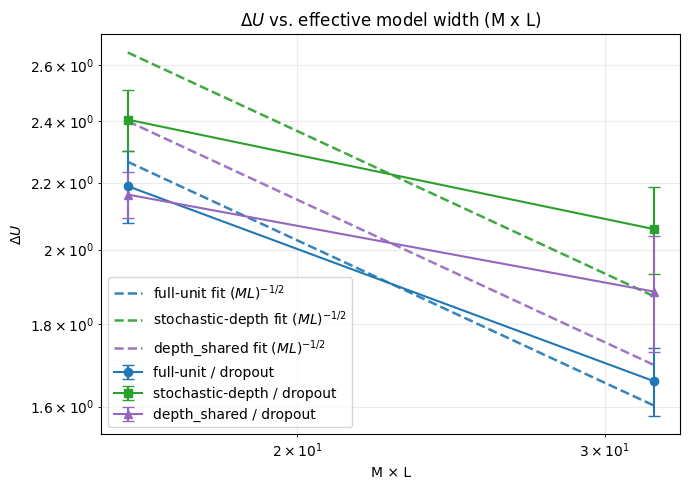

In [11]:
figU = plot_metric_vs_ML(df_results, metric='Delta_U', log_x=True, log_y=True, fit_ml_inv_sqrt=True)

In [12]:
#figU.savefig("plots/Delta_U_vs_ML.pdf")

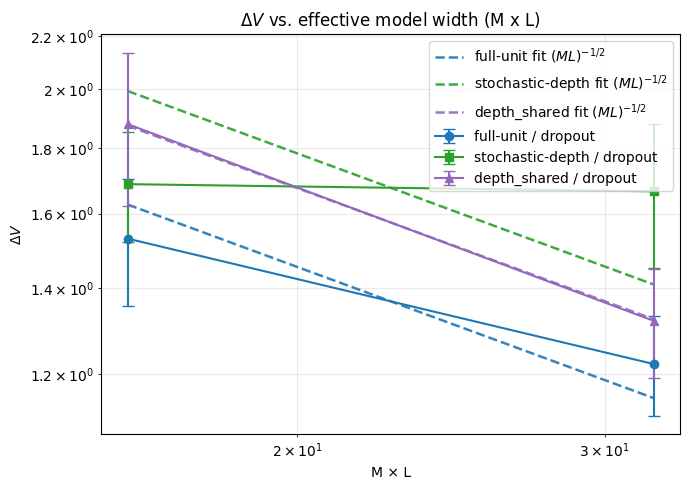

In [13]:
figV = plot_metric_vs_ML(df_results, metric='Delta_V', log_x=True, log_y=True, fit_ml_inv_sqrt=True)

In [14]:
#figV.savefig("plots/Delta_V_vs_ML.pdf")

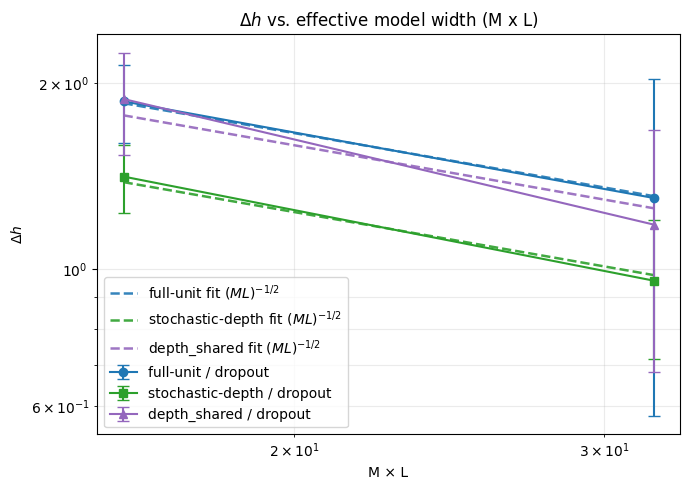

In [15]:
figh = plot_metric_vs_ML(df_results, metric='Delta_h', log_x=True, log_y=True, fit_ml_inv_sqrt=True)

In [16]:
#figh.savefig("plots/Delta_h_vs_ML.pdf")

In [ ]:
#D, L, M = 10, 400, 400 #Demora ~11min
D, L, M = 10, 400, 40 #Demora ~11min
tau = 0.4 # 0.2
n_steps = 200 #200
lr_in, lr_out = 0.0, 0.0
q = 0.5
batch_size = 64
last_particle_single_source = True

num_repetitions = 5
LOOP_SEED = 48

In [ ]:
params0 = init_params(random.PRNGKey(seed + 44), d_in, d_out, D, L, M)
params0 = align_tracked_particle_across_layers(params0, particle_idx=-1)

In [ ]:
import pickle


#setting_str = f'L{L}_M{M}_D{D}_tau{tau}_q{q}_nsteps{n_steps}_din{d_in}_dout{d_out}_seed{seed}_N{N}_loopseed{LOOP_SEED}'
#setting_str = f'L{L}_M{M}_D{D}_tau{tau}_q{q}_nsteps{n_steps}_din{d_in}_dout{d_out}_seed{seed}_N{N}_numrepetitions{num_repetitions}_loopseed{LOOP_SEED}'
setting_str = f'L{L}_M{M}_D{D}_tau{tau}_q{q}_nsteps{n_steps}_din{d_in}_dout{d_out}_seed{seed}_N{N}_numrepetitions{num_repetitions}_loopseed{LOOP_SEED}_batchsize{batch_size}_lpss{last_particle_single_source}'


# Export (serialize) to pickle
with open(f'data/mnist/final_params_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_gd = pickle.load(f)

with open(f'data/mnist/histories_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_gd = pickle.load(f)

with open(f'data/mnist/final_params_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_do = pickle.load(f)

with open(f'data/mnist/histories_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_do = pickle.load(f)

with open(f'data/mnist/final_params_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_ram = pickle.load(f)

with open(f'data/mnist/histories_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_ram = pickle.load(f)


In [ ]:
def get_predictions(output):
    if isinstance(output, dict):
        return output["test_output"].argmax(axis=-1)
    return output.argmax(axis=-1)

In [ ]:
def plot_test_images(X_test, Y_test, prediction, n_rows=3, n_cols=4):
    n_show = n_rows * n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 9))
    axes = axes.ravel()

    # Support both one-hot and integer ground-truth labels.
    if getattr(Y_test, "ndim", 1) > 1:
        y_true = np.asarray(Y_test).argmax(axis=-1)
    else:
        y_true = np.asarray(Y_test)

    y_pred = np.asarray(prediction)

    for i in range(n_show):
        ax = axes[i]
        ax.imshow(np.asarray(X_test[i]).reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[i]} | GT: {y_true[i]}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

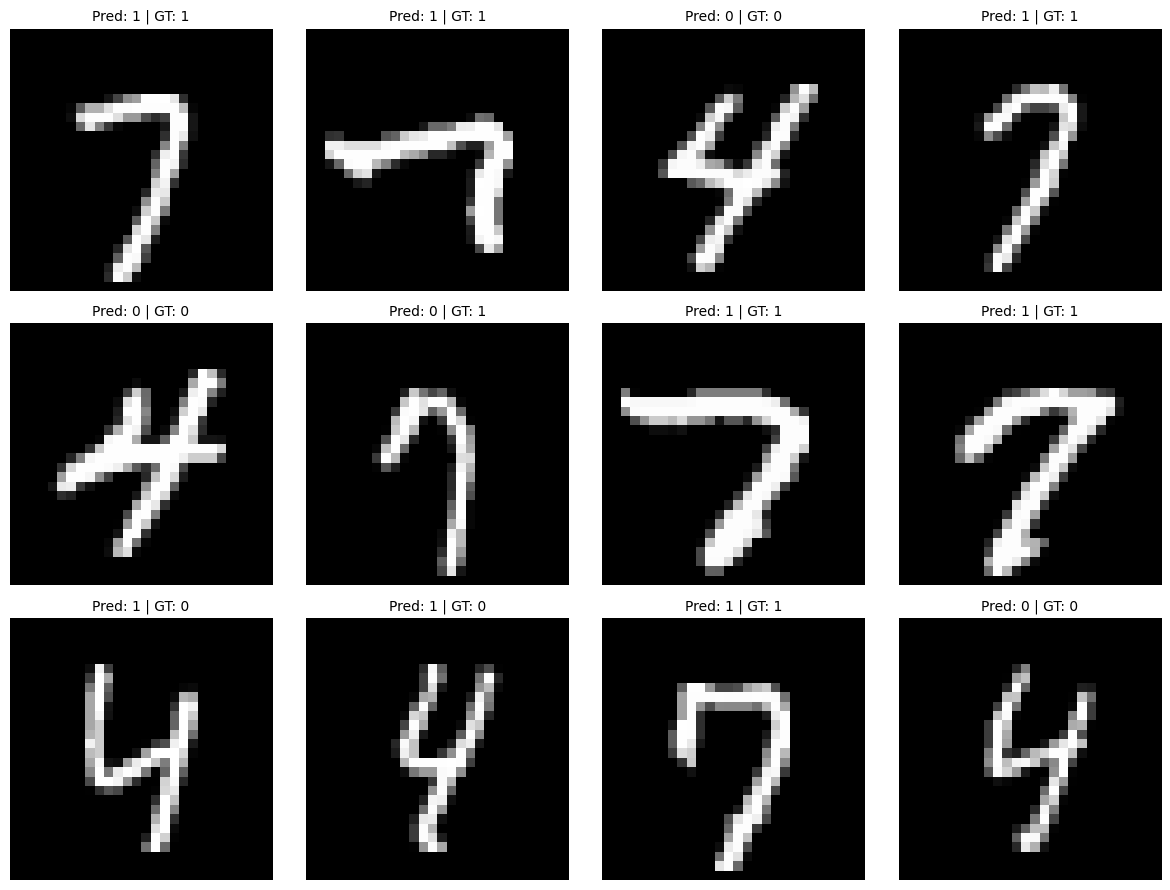

In [ ]:
predictions = get_predictions(histories_do["full_unit_dropout"][0]["test_output"])
plot_test_images(X_test, Y_test, predictions)

In [ ]:
def compute_accuracy(predictions, Y_test):
    return 1- jnp.abs(predictions - Y_test.argmax(axis=1)).sum()/Y_test.shape[0]

In [ ]:
predictions_do1 = get_predictions(histories_do["full_unit_dropout"][0])
predictions_ram1 = get_predictions(histories_ram["full_unit_dropout"][0])
predictions_do2 = get_predictions(histories_do["stochastic_depth"][0])
predictions_ram2 = get_predictions(histories_ram["stochastic_depth"][0])
predictions_gd = get_predictions(histories_gd["gd"][0])

In [ ]:

print(compute_accuracy(predictions_do1, Y_test))
print(compute_accuracy(predictions_ram1, Y_test))
print(compute_accuracy(predictions_do2, Y_test))
print(compute_accuracy(predictions_ram2, Y_test))
print(compute_accuracy(predictions_gd, Y_test))

0.862
0.8625
0.86300004
0.8565
0.8505


In [ ]:
# Compare test loss across GD, Dropout and RaM for selected variants

def plot_test_loss_compare_all_runs(show=True, xlim=None, ylim=None):
    """Plot mean ± std of test loss over iterations for GD, full_unit, and stochastic_depth runs."""
    run_specs = {
        'GD': histories_gd["gd"],
        'Dropout (full-unit)': histories_do["full_unit_dropout"],
        'RaM (full-unit)': histories_ram["full_unit_dropout"],
        'Dropout (stochastic depth)': histories_do["stochastic_depth"],
        'RaM (stochastic depth)': histories_ram["stochastic_depth"],
    }
    run_colors = {
        'GD': 'black',
        'Dropout (full-unit)': 'tab:blue',
        'RaM (full-unit)': 'tab:blue',
        'Dropout (stochastic depth)': 'tab:green',
        'RaM (stochastic depth)': 'tab:green',
    }
    run_linestyles = {
        'GD': '-',
        'Dropout (full-unit)': '--',
        'RaM (full-unit)': '-',
        'Dropout (stochastic depth)': '--',
        'RaM (stochastic depth)': '-',
    }

    steps = np.arange(len(histories_gd["gd"][0]['test_loss']))
    fig, ax = plt.subplots(figsize=(9, 5))

    for run_name, run_history in run_specs.items():
        values = np.stack([np.asarray(h['test_loss']) for h in run_history], axis=0)
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        color = run_colors[run_name]
        linestyle = run_linestyles[run_name]
        ax.plot(steps, mean, label=run_name, color=color, linestyle=linestyle)
        ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

    #ax.set_yscale('log')
    ax.set_title('Test loss comparison')
    ax.set_xlabel('step')
    ax.set_ylabel('test loss')
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend()

    fig.tight_layout()
    if show:
        plt.show()
    return fig

In [ ]:
# Compare train, noiseless train, and test loss for GD, Dropout and RaM for a chosen variant
def plot_train_test_compare(chosen_variant):
    metric_specs = [
        ('train_loss', 'Train Loss'),
        ('noiseless_train_loss', 'Noiseless Train Loss'),
        ('test_loss', 'Test Loss'),
    ]

    run_specs = {
        'GD': histories_gd["gd"],
        'Dropout': histories_do[chosen_variant],
        'RaM': histories_ram[chosen_variant],
    }
    run_colors = {
        'GD': 'black',
        'Dropout': 'tab:blue',
        'RaM': 'tab:orange',
    }
    steps = np.arange(len(histories_gd["gd"][0]['train_loss']))

    fig, axes = plt.subplots(1, len(metric_specs), figsize=(5 * len(metric_specs), 4), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, (metric_key, title) in zip(axes, metric_specs):
        for run_name, run_history in run_specs.items():
            color = run_colors[run_name]
            # if run_name == 'GD':
            #     values = np.asarray(run_history[metric_key])
            #     ax.plot(steps, values, label=run_name, color=color)
            # else:
            values = np.stack([np.asarray(h[metric_key]) for h in run_history], axis=0)
            mean = values.mean(axis=0)
            std = values.std(axis=0)
            ax.plot(steps, mean, label=run_name, color=color)
            ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.2)

        ax.set_yscale('log')
        ax.set_title(title)
        ax.set_xlabel('step')
        ax.set_ylabel('loss')
        ax.legend()

    fig.suptitle(f'Loss comparison (variant={chosen_variant})')
    fig.tight_layout()
    plt.show()
    return fig

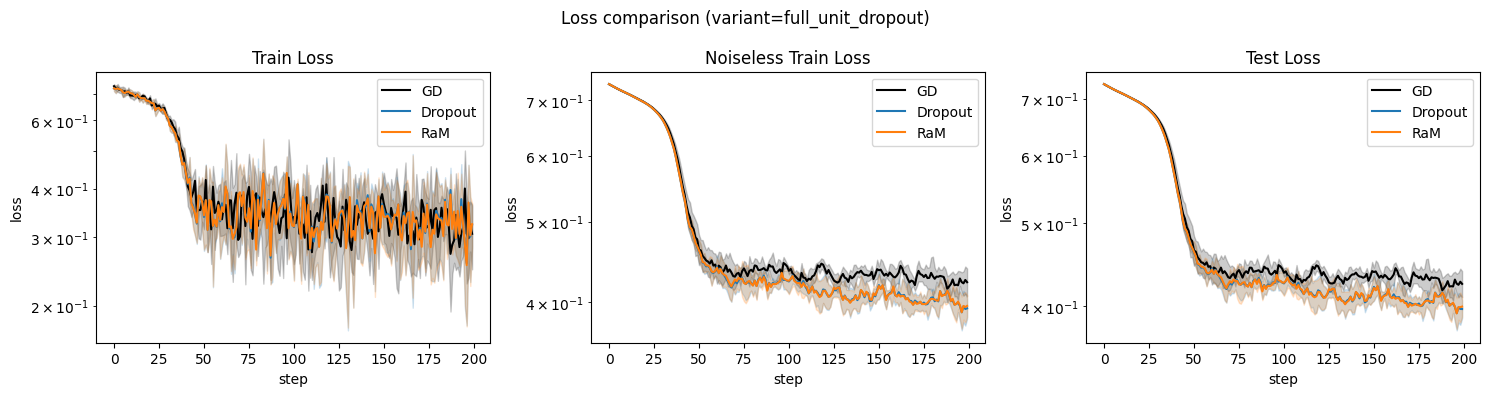

In [ ]:
# Call for the currently selected variant (must be set earlier)
fig1 = plot_train_test_compare("full_unit_dropout")

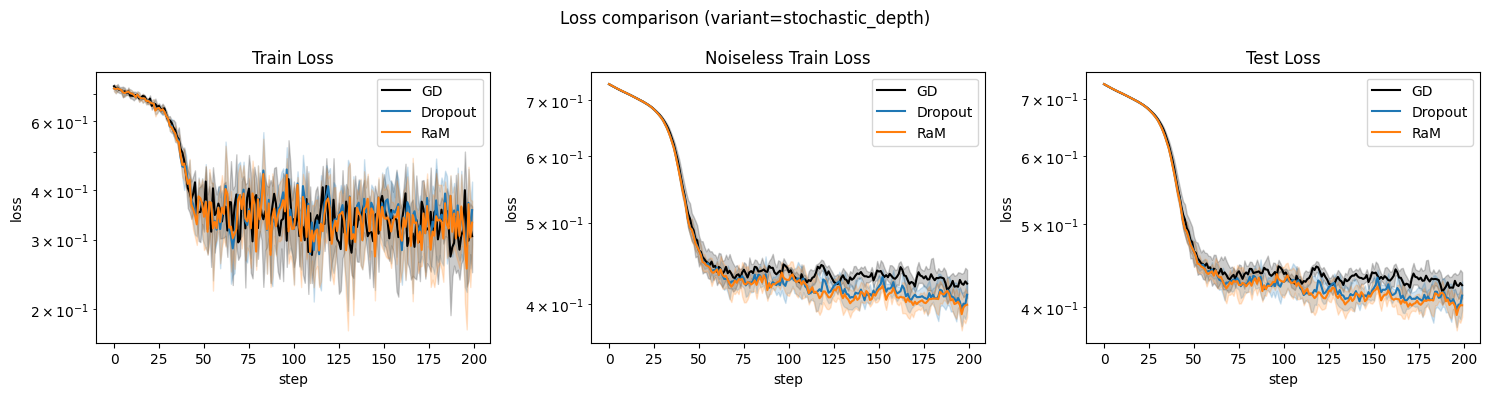

In [ ]:
# Call for the currently selected variant (must be set earlier)
fig2 = plot_train_test_compare("stochastic_depth")

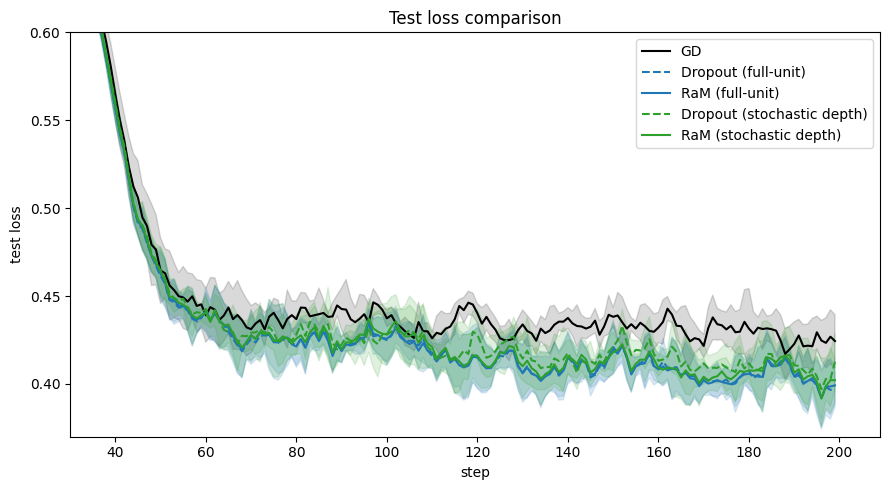

In [ ]:
fig = plot_test_loss_compare_all_runs(xlim=(30, None), ylim=(0.37, 0.6))

In [ ]:
# No second plot needed.

In [ ]:
def plot_compare_final_params(
        params_list,
        labels,
        params_init=None,
        n_dims=6,
        particle_idx=-1,
        include_v=True,
        show=True,
    ):
        """Plot and compare final U/V parameters across multiple training runs with optional init overlay.

        Args:
            params_list: list of parameter objects (e.g., [params_do, params_ram, params_gd])
            labels: list of labels for legend (e.g., ['dropout', 'ram', 'gd'])
            params_init: optional initial parameters to overlay as dashed lines
            n_dims: number of dimensions to plot
            particle_idx: which particle to extract
            include_v: whether to plot V parameters
            show: whether to display the plot
        """
        colors = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple')[:len(params_list)]

        # Extract U and V from all params
        param_data = []
        for params in params_list:
            param_data.append((np.asarray(params.U), np.asarray(params.V)))

        U_init, V_init = None, None
        if params_init is not None:
            U_init, V_init = np.asarray(params_init.U), np.asarray(params_init.V)

        L, _, D = param_data[0][0].shape
        n_dims = int(min(n_dims, D))
        layer_idx = np.arange(L)
        selected_dims = np.arange(n_dims)
        n_rows = 2 if include_v else 1
        _fig, axes = plt.subplots(n_rows, n_dims, figsize=(3.6 * n_dims, 3.2 * n_rows), sharex=True, squeeze=False)

        for col, d in enumerate(selected_dims):
            # Plot U
            ax_u = axes[0, col]
            if U_init is not None:
                ax_u.plot(layer_idx, U_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='init' if col == 0 else None)
            for (u_arr, _), label, color in zip(param_data, labels, colors):
                ax_u.plot(layer_idx, u_arr[:, particle_idx, d], color=color, linewidth=1.6, label=label if col == 0 else None)
            ax_u.set_title(f'U[:, {particle_idx}, {d}]')
            ax_u.grid(alpha=0.2)
            if col == 0:
                ax_u.set_ylabel('U value')
                ax_u.legend(loc='best', fontsize=8)

            # Plot V
            if include_v:
                ax_v = axes[1, col]
                if V_init is not None:
                    ax_v.plot(layer_idx, V_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='init' if col == 0 else None)
                for (_, v_arr), label, color in zip(param_data, labels, colors):
                    ax_v.plot(layer_idx, v_arr[:, particle_idx, d], color=color, linewidth=1.6, label=label if col == 0 else None)
                ax_v.set_title(f'V[:, {particle_idx}, {d}]')
                ax_v.grid(alpha=0.2)
                if col == 0:
                    ax_v.set_ylabel('V value')
                    ax_v.legend(loc='best', fontsize=8)

        for col in range(n_dims):
            axes[-1, col].set_xlabel('layer l')

        _fig.suptitle('U/V comparison across runs', y=1.02)
        _fig.tight_layout()
        if show:
            plt.show()
        return _fig

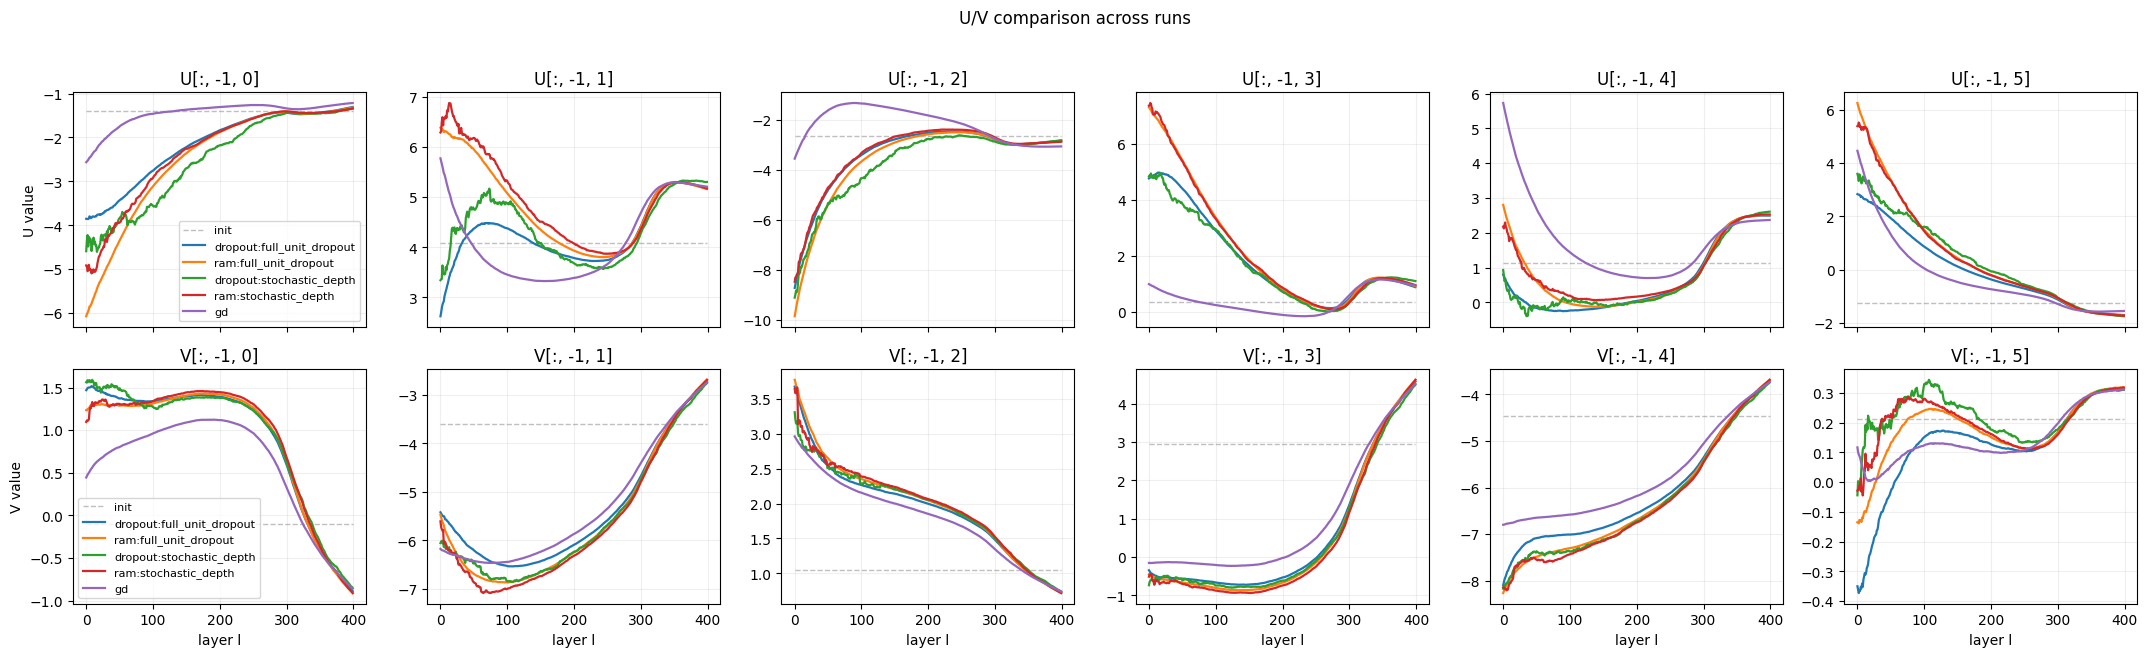

In [ ]:
chosen_variant_do1, chosen_variant_ram1 = "full_unit_dropout", "full_unit_dropout"
chosen_variant_do2, chosen_variant_ram2 = "stochastic_depth", "stochastic_depth"
rep_chosen = 2
comparison_three = plot_compare_final_params(
    [final_params_do[chosen_variant_do1][rep_chosen],
     final_params_ram[chosen_variant_ram1][rep_chosen],
     final_params_do[chosen_variant_do2][rep_chosen],
     final_params_ram[chosen_variant_ram2][rep_chosen],
     final_params_gd["gd"][rep_chosen]],
    [f"dropout:{chosen_variant_do1}", 
    f"ram:{chosen_variant_ram1}", 
    f"dropout:{chosen_variant_do2}", 
    f"ram:{chosen_variant_ram2}", 
    "gd"],
    params_init=params0,
    n_dims=min(6, D),
    particle_idx=-1,
    include_v=True,
    show=False,
)

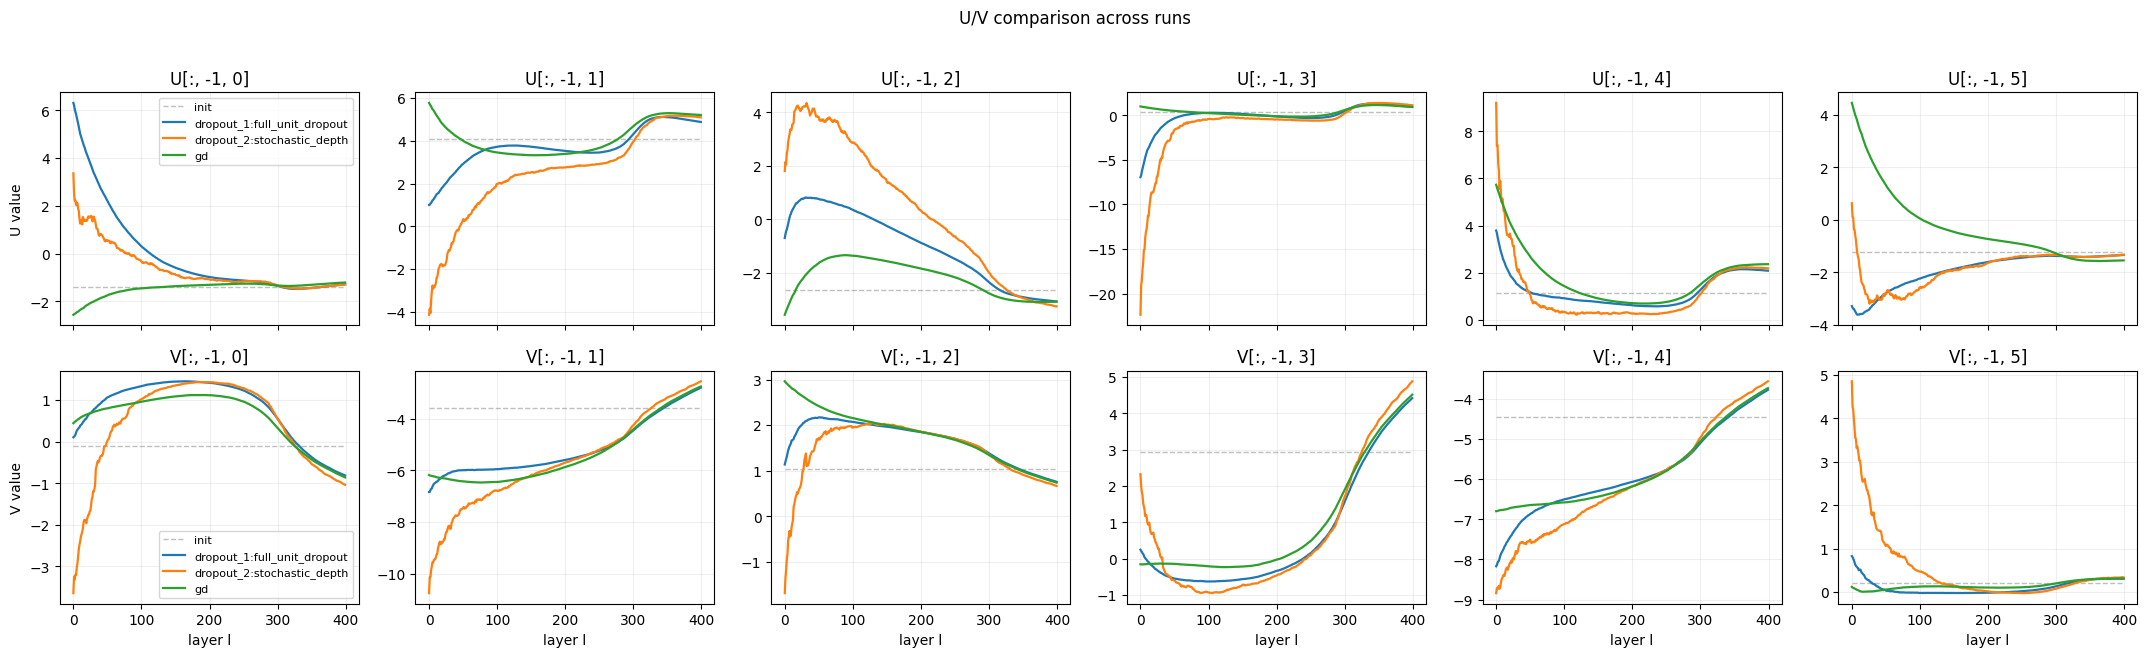

In [ ]:
chosen_variant_do1, chosen_variant_do2 = "full_unit_dropout", "stochastic_depth"
comparison_four = plot_compare_final_params(
    [final_params_do[chosen_variant_do1][0], final_params_do[chosen_variant_do2][0], final_params_gd["gd"][rep_chosen]],
    [f"dropout_1:{chosen_variant_do1}", f"dropout_2:{chosen_variant_do2}", "gd"],
    params_init=params0,
    n_dims=min(6, D),
    particle_idx=-1,
    include_v=True,
    show=False,
)

In [ ]:
chosen_variant_do = "stochastic_depth"#"full_unit_dropout"
all_Hs = [histories_do[chosen_variant_do][j]["test_h"].transpose(2,0,1) for j in range(num_repetitions)]

H_limit = histories_ram[chosen_variant_do][0]["test_h"].transpose(2,0,1) #history_gd["test_h"][-1].transpose(2,0,1)
all_Hs[0].shape, H_limit.shape

((10, 2000, 401), (10, 2000, 401))

In [ ]:

import numpy as np
def interpolate_H_layers(H, t_target):
    t_source = np.linspace(0.0, 1.0, H.shape[2])
    H_interp = np.empty((H.shape[0], H.shape[1], len(t_target)))
    for d in range(H.shape[0]):
        for n in range(H.shape[1]):
            H_interp[d, n, :] = np.interp(t_target, t_source, H[d, n, :])
    return H_interp

target_len = max([H.shape[2] for H in all_Hs] + [H_limit.shape[2]])
t_common = np.linspace(0.0, 1.0, target_len)

all_Hs_interp = [interpolate_H_layers(H, t_common) for H in all_Hs]
H_limit_interp = interpolate_H_layers(H_limit, t_common)

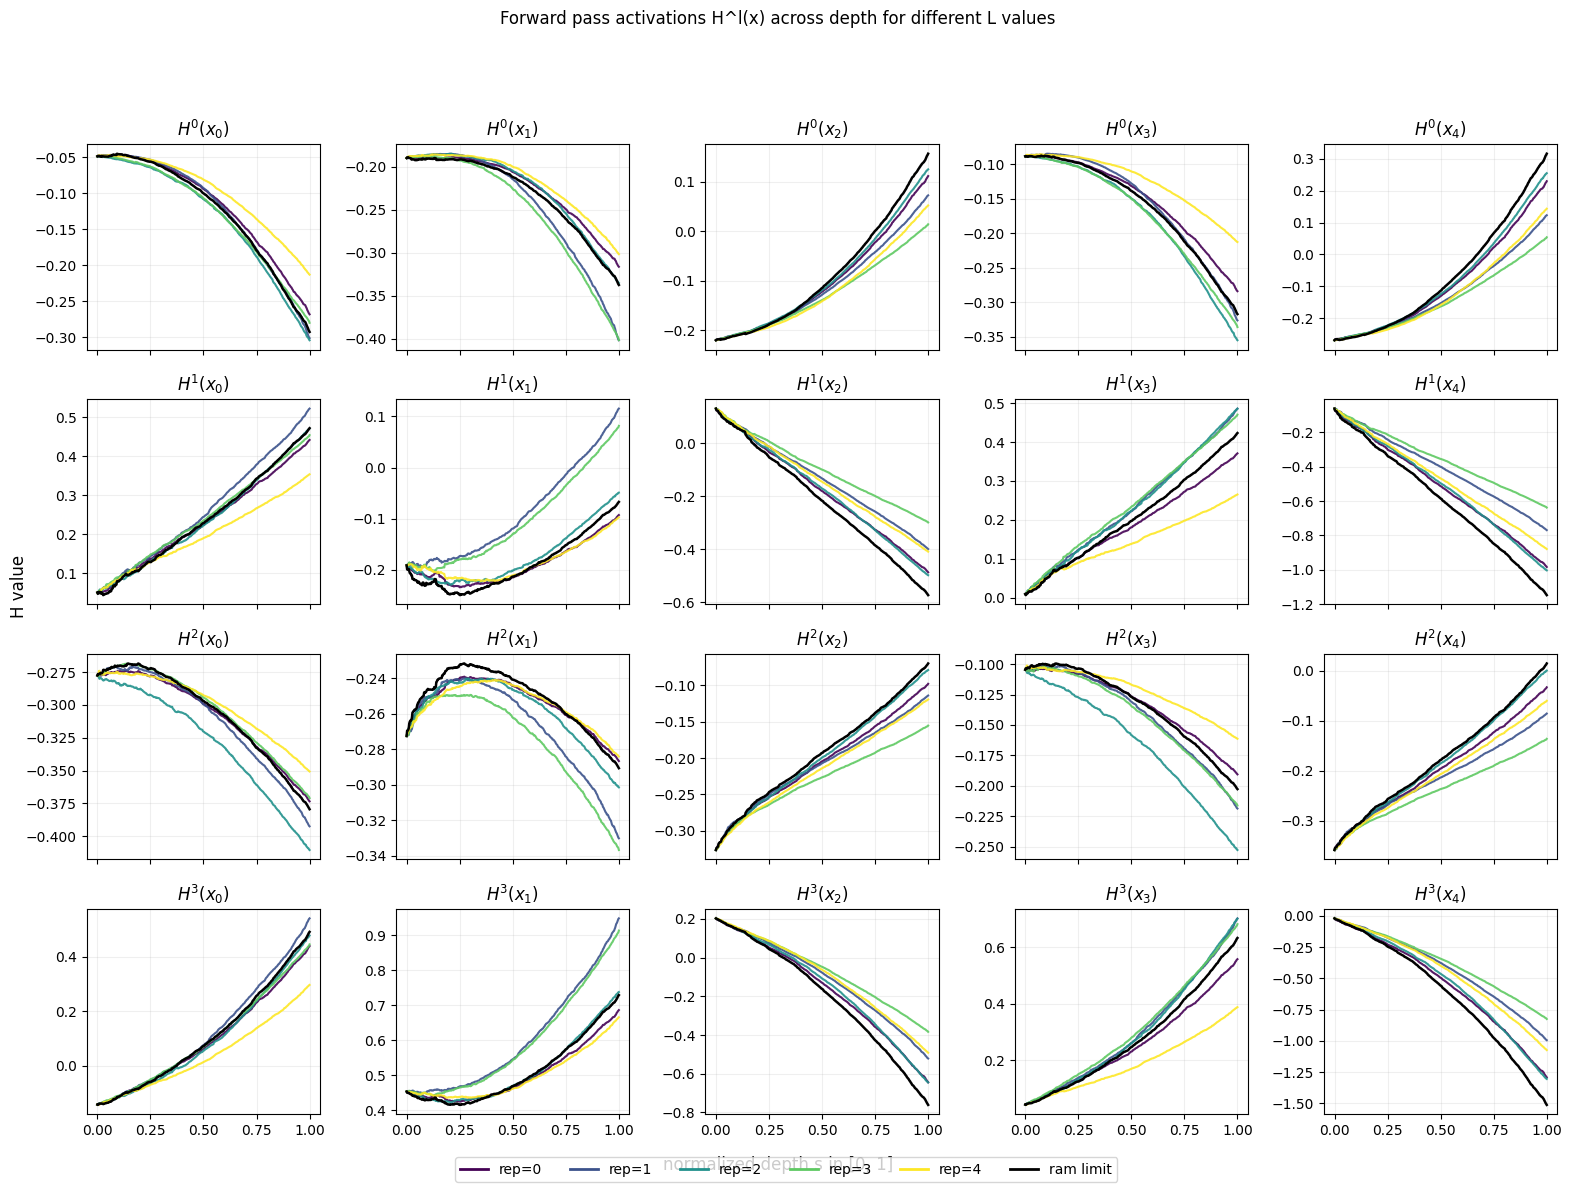

In [ ]:
repetitions = list(range(num_repetitions))
dims, points = 4, 5
fig, axes = plt.subplots(dims, points, figsize=(16, 12), sharex=True)
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0.0, 1.0, len(repetitions)))

for i in range(dims):
    for j in range(points):
        ax = axes[i, j]
        for rep, H_interp, color in zip(repetitions, all_Hs_interp, colors):
            ax.plot(t_common, H_interp[i, j, :], color=color, alpha=0.9)
        ax.plot(t_common, H_limit_interp[i, j, :], color='black', linewidth=1.8)
        ax.set_title(rf'$H^{i}(x_{j})$')
        ax.grid(alpha=0.2)

# Shared labels
fig.supxlabel('normalized depth s in [0, 1]')
fig.supylabel('H value')

# One shared legend for L values + no-dropout reference
legend_lines = [
    plt.Line2D([0], [0], color=color, lw=2, label=f'rep={rep}')
    for rep, color in zip(repetitions, colors)
]
legend_lines.append(
    plt.Line2D([0], [0], color='black', lw=2, label='ram limit')
)
fig.legend(handles=legend_lines, loc='lower center', ncol=min(len(legend_lines), 7))
fig.suptitle("Forward pass activations H^l(x) across depth for different L values")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
## Track Parameters

In [ ]:
# Dropout vs RaM
metrics_do = compute_parameter_distance_metrics(
    final_params_do[chosen_variant_do],
    final_params_ram[chosen_variant_do],
    histories_do[chosen_variant_do],
    histories_ram[chosen_variant_do],
    variant_name=f"dropout:{chosen_variant_do}"
)

print(f"\n=== {chosen_variant_do} ===")
print(f"Dropout vs GD:")
print(f"  ΔU = {metrics_do['Delta_U']:.4e} ± {metrics_do.get('Delta_U_std', 0):.4e}")
print(f"  ΔV = {metrics_do['Delta_V']:.4e} ± {metrics_do.get('Delta_V_std', 0):.4e}")
print(f"  Δh = {metrics_do['Delta_h']:.4e} ± {metrics_do.get('Delta_h_std', 0):.4e}")


=== stochastic_depth ===
Dropout vs GD:
  ΔU = 6.3620e-01 ± 8.6717e-02
  ΔV = 4.2135e-01 ± 4.8928e-02
  Δh = 9.4850e-02 ± 1.2972e-02
